In [1]:
from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sb = fits.open('Halpha_moment0.fits')[0].data.astype(float)
cont = fits.open('Halpha_continuum_map.fits')[0].data.astype(float)

C:\Users\javas\AppData\Local\Temp\ipykernel_35652\4163977964.py:8: RuntimeWarning: invalid value encountered in log10
  im = axx.imshow(np.log10(sb), **imshow_kwds2)


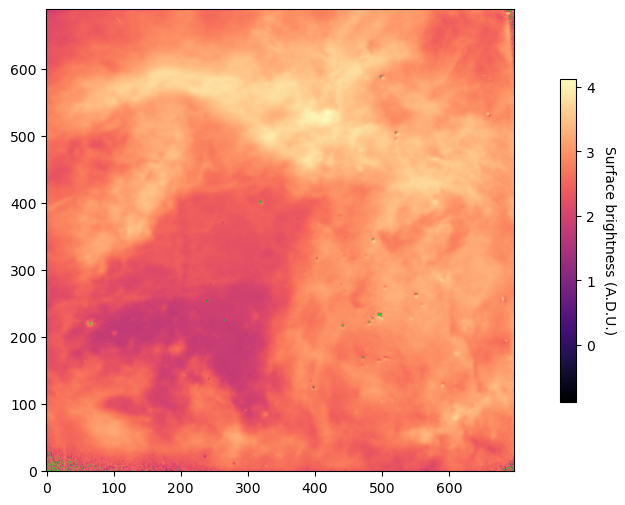

In [3]:
fig, (axx) = plt.subplots(
    1,
    1,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = axx.imshow(np.log10(sb), **imshow_kwds2)
im.cmap.set_bad(color='limegreen')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')

In [10]:
m = ~np.isfinite(sb) | (sb < 0.0)
sb[m] = 0.0
sb   /= sb.max()
mask_sb = sb > 0.005

In [11]:
sb_m = np.where(mask_sb, sb, np.nan)     

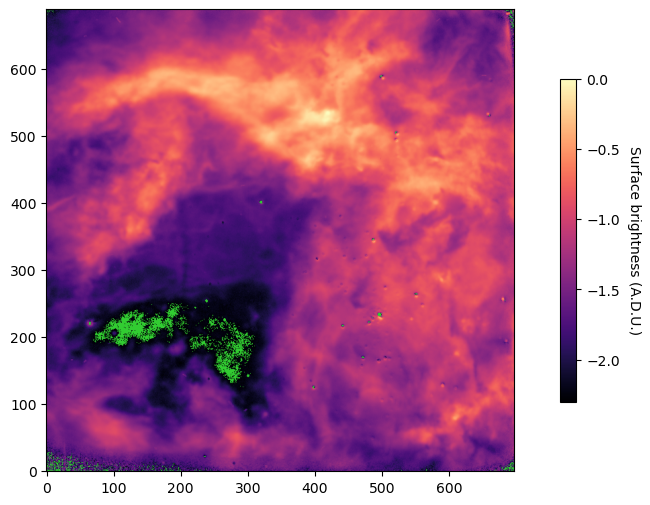

In [12]:
fig, (axx) = plt.subplots(
    1,
    1,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = axx.imshow(np.log10(sb_m), **imshow_kwds2)
im.cmap.set_bad(color='limegreen')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')